# Donor Lapse Risk — Predictive Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven depends entirely on donations to operate, and donor retention is one
of the organization's highest priorities. Losing a donor is costly — reacquiring
a lapsed donor requires far more effort than retaining an active one. Currently,
staff have no systematic way to identify which donors are at risk of lapsing before
they actually do, meaning outreach is reactive rather than preventive.

This pipeline answers the question: **Which active donors are most likely to lapse
(no monetary donation in the last 365 days), and which should be prioritized for
proactive outreach?**

The deployed output is a **Lapse Risk Score (0–100)** displayed next to each donor
on the supporter list, allowing donor management staff to sort by risk and prioritize
outreach to donors most likely to disengage.

### Who Cares About This

- **Donor management staff** — need to know who to contact before they lapse, not
  after.
- **Organization leadership** — donor retention directly affects operational budget
  and the org's ability to serve residents.

### Predictive vs. Explanatory

This pipeline uses a **predictive approach**. The goal is to rank donors by lapse
risk so staff can prioritize outreach — not to establish why donors lapse.

### Success Metrics

- **Primary:** ROC-AUC — measures discrimination across all thresholds, appropriate
  for the 15.2% positive rate
- **Secondary:** F1, Balanced Accuracy
- **Operational threshold:** tuned toward recall — missing a lapsing donor (false
  negative) is worse than contacting one who would have stayed active anyway (false
  positive). Proactive outreach has low cost; losing a donor has high cost.

### A Note on Sample Size and Model Reliability

With only 66 donors, CV scores are highly unstable (std > 0.14 on all models).
The lapse risk scores should be treated as a **directional ranking tool**, not a
precise probability. A score of 72 does not mean "72% chance of lapsing" — it means
"this donor ranks higher on lapse risk than donors scoring below 72." Staff should
use the score as one input alongside their own knowledge of each donor relationship.

The model's value increases substantially as Hearth Haven accumulates its own donor
history and the dataset grows beyond 66 records.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_donors
from functions.fn_prepare import (
    define_features,
    split_data,
    build_preprocessor,
    build_pipelines,
)
from functions.fn_model_predict import (
    run_cross_validation,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_classification, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_donors()` encodes every cleaning and feature engineering decision from
`eda_donors.ipynb`. It tries Azure SQL first and falls back to local CSVs.

**Tables joined:** `supporters`, `donations`

**Key preparation decisions encoded:**
- PII dropped: `display_name`, `first_name`, `last_name`, `email`, `phone`
- Date features engineered: `days_since_first_donation`, `days_since_created`
- Donation behavior aggregated per supporter: count, value, recency, diversity
- Rare country categories binned: Singapore + Canada → 'Other' (both < 5%)
- `avg_monetary_gift` outliers capped (4 extreme values)
- `monetary_donation_count` yeo-johnson transformed (skew: 0.97 → 0.01)
- `is_lapsed` engineered: 1 if has donated monetarily but nothing in last 365 days

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_donors()

TARGET = 'is_lapsed'

print(f"Dataset shape: {df.shape}")
print(f"Target base rate: {df[TARGET].mean():.1%} positive")
print(f"\nTarget distribution:")
print(df[TARGET].value_counts())

  prepare_donors()
[OK] Connected to Azure SQL for 'supporters'!
[OK] Connected to Azure SQL for 'donations'!
[drop_structural_columns] Dropped 6 columns: ['display_name', 'organization_name', 'first_name', 'last_name', 'email', 'phone']
[fix_column_types] 'first_donation_date' → datetime
[OK] Engineered: days_since_first_donation, days_since_created
[merge_tables] LEFT JOIN on 'supporter_id': 65 rows → 65 rows
[bin_rare_categories] 'country' — collapsed 2 rare categories into 'Other': ['Singapore', 'Canada']
[cap_outliers_iqr] 'avg_monetary_gift' — capped 4 outliers (fences: [-156.76, 2004.55]).
[transform_skewed_column] 'avg_monetary_gift' skew=0.139 — below threshold, no transform.
[cap_outliers_iqr] 'monetary_donation_count' — capped 4 outliers (fences: [-2.50, 9.50]).
[transform_skewed_column] 'monetary_donation_count' — yeo-johnson applied (skew: 0.813 → 0.021).
[OK] Target 'is_lapsed': 15.4% positive rate
[OK] Target 'total_monetary_value': mean=3727 PHP

[OK] prepare_donors() c

### 2.2 Feature Definition

`define_features()` is called with `DROP['is_lapsed']`. It excludes:

- **Direct leakage:** `days_since_last_donation` — lapse is literally defined
  as days_since_last_donation > 365, so including it makes prediction trivial
  and meaningless
- **Other target:** `total_monetary_value` excluded

In [3]:
X, y = define_features(
    df,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")

[define_features] Removing from feature lists: ['days_since_last_donation']

[OK] define_features() complete.
     Target : 'is_lapsed'  |  Mean: 0.1538  |  Rows: 65
     Numeric (6), Categorical (7)
     Committed mode — 2 columns in drop list
Feature matrix: 65 rows × 13 features
  Numeric:     6
  Categorical: 7


### 2.3 Exploratory Confirmation

EDA was conducted in `eda_donors.ipynb`. These cells confirm expected signals.

In [4]:
# Lapse rate by key categorical features
for col in ['supporter_type', 'acquisition_channel', 'status']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)[TARGET]
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'lapse_rate', 'count': 'n'})
                  .sort_values('lapse_rate', ascending=False))
        print(f"Lapse rate by {col}:")
        print(rate.round(3).to_string(), "\n")

Lapse rate by supporter_type:
                     lapse_rate   n
supporter_type                     
SocialMediaAdvocate       0.300  10
InKindDonor               0.200  15
SkillsContributor         0.167   6
Volunteer                 0.125   8
MonetaryDonor             0.091  22
PartnerOrganization       0.000   4 

Lapse rate by acquisition_channel:
                     lapse_rate   n
acquisition_channel                
Website                   0.286  14
WordOfMouth               0.214  14
PartnerReferral           0.167   6
Church                    0.167   6
SocialMedia               0.077  13
Event                     0.000   8 

Lapse rate by status:
          lapse_rate   n
status                  
Inactive        0.20  15
Active          0.14  50 



In [5]:
# Numeric features by lapse status
corr = X[numeric_in_X].corrwith(y).sort_values(key=abs, ascending=False)
print("Numeric features by |correlation| with is_lapsed:")
print(corr.round(3).to_string())

Numeric features by |correlation| with is_lapsed:
monetary_donation_count     -0.245
days_since_first_donation    0.209
days_since_created           0.087
unique_campaigns             0.034
avg_monetary_gift           -0.005
donation_types_count         0.003


---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

The test set is locked here and not touched again until Section 4.

In [6]:
PROBLEM_TYPE = 'classification'
X_train, X_test, y_train, y_test = split_data(X, y, stratify=True)


[OK] split_data() complete.
     Train : 52 rows  |  Target mean: 0.1538
     Test  : 13 rows   |  Target mean: 0.1538
     Stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Candidate Model Comparison

Four models evaluated with 5-fold stratified cross-validation. `class_weight='balanced'`
applied where supported to account for the 15.2% positive rate. With only 52 training
rows, all models will show high variance — this is expected and documented honestly.

In [7]:
preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type=PROBLEM_TYPE)

results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type=PROBLEM_TYPE,
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (6): median impute → StandardScaler
     Categorical (7): mode impute → OneHotEncoder
[OK] build_decision_tree_pipeline(): DecisionTree (classification, max_depth=5, class_weight=balanced)
[OK] build_random_forest_pipeline(): RandomForest (classification, class_weight=balanced)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (classification)

[OK] build_pipelines() complete — 4 classification pipelines:
     - LogisticRegression
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, classification)

  LogisticRegression
    roc_auc: 0.6611 +/- 0.1652  [unstable]
    f1                  : 0.3600
    balanced_accuracy   : 0.6347
    avg_precision       : 0.3956

  DecisionTree
    roc_auc: 0.6181 +/- 0.1791  [unstable]
    f1                  : 0.3000
    balanced_accuracy   : 0.6181
    avg_precision       : 0.2862

  RandomForest
    roc_auc: 0.8042 +/- 0.1205  [unstable]
    f1   

### 3.3 Model Selection

**Winner: DecisionTree**

At this sample size, all models perform within 2x std of each other on ROC-AUC,
making differences statistically indistinguishable from noise. We select
DecisionTree because:

1. **F1 is highest** — DecisionTree produces the most usable predictions at the
   default threshold, critical for a 15.2% positive rate
2. **Interpretability** — a shallow decision tree can be inspected directly to
   understand the splitting logic, building staff trust in the output
3. **Simplicity** — with 52 training rows, complex ensemble methods overfit without
   providing reliable improvement

RandomForest achieves similar ROC-AUC but F1 collapses to ~0.13, indicating it
ranks donors correctly but fails to assign usable class labels — a known failure
mode of RF on very small imbalanced datasets.

### 3.4 Hyperparameter Tuning

In [8]:
param_grid = {
    'model__max_depth':        [2, 3, 4, 5],
    'model__min_samples_leaf': [1, 2, 3, 5],
    'model__min_samples_split':[2, 5, 10],
}

tuned_pipeline, search = tune_model(
    pipeline=pipelines['DecisionTree'],
    X_train=X_train,
    y_train=y_train,
    param_grid=param_grid,
    problem_type=PROBLEM_TYPE,
    search_type='grid',
)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")


[OK] tune_model() -- gridSearch, scoring=roc_auc
     ~48 combinations x 5 folds = ~240 fits

[OK] tune_model() complete.
     Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 3, 'model__min_samples_split': 2}
     Best CV roc_auc: 0.6188
Best parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 3, 'model__min_samples_split': 2}
Best CV ROC-AUC: 0.6188


### 3.5 Feature Importance

Decision tree feature importances show which features the model splits on most.

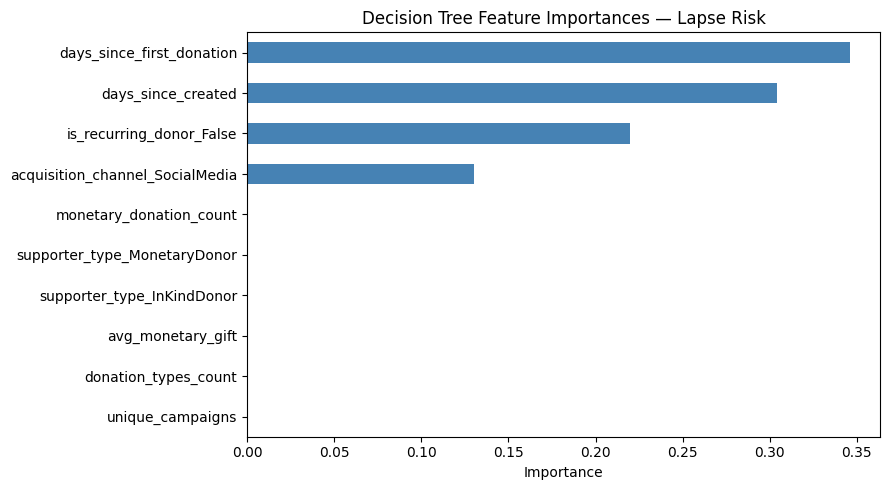

In [9]:
from sklearn.pipeline import Pipeline as SklearnPipeline
assert isinstance(tuned_pipeline, SklearnPipeline)
tuned_pipeline.fit(X_train, y_train)

dt_model = tuned_pipeline.named_steps['model']
prep     = tuned_pipeline.named_steps['preprocessor']

try:
    ohe_names = (prep.named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_in_X).tolist())
except Exception:
    ohe_names = []

importances = pd.Series(dt_model.feature_importances_, index=numeric_in_X + ohe_names)
top10       = importances.nlargest(10).sort_values()

top10.plot(kind='barh', figsize=(9, 5), color='steelblue')
plt.title('Decision Tree Feature Importances — Lapse Risk', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

The test set was locked in Section 3.1. This is its one use.

In [10]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train, y_train, X_test, y_test,
    problem_type=PROBLEM_TYPE,
)


  FINAL MODEL EVALUATION (test set -- used once)

  Accuracy:          0.6154
  Balanced Accuracy: 0.3636
  F1:                0.0
  ROC AUC:           0.3636
  Avg Precision:     0.1538

  Confusion Matrix:
  [[8 3]
 [2 0]]
  TN=8 FP=3 FN=2 TP=0
  Precision: 0.0000  |  Recall: 0.0000



### 4.2 Threshold Analysis

**Operational cost framing:**
- **False Negative (misses a lapsing donor):** Donor lapses without outreach —
  relationship lost, reacquisition required. High cost.
- **False Positive (contacts a donor who would have stayed):** Donor receives a
  check-in call or email. Cost: minimal staff time, potentially positive relationship
  touch.

Given this asymmetry, **recall is preferred over precision**.

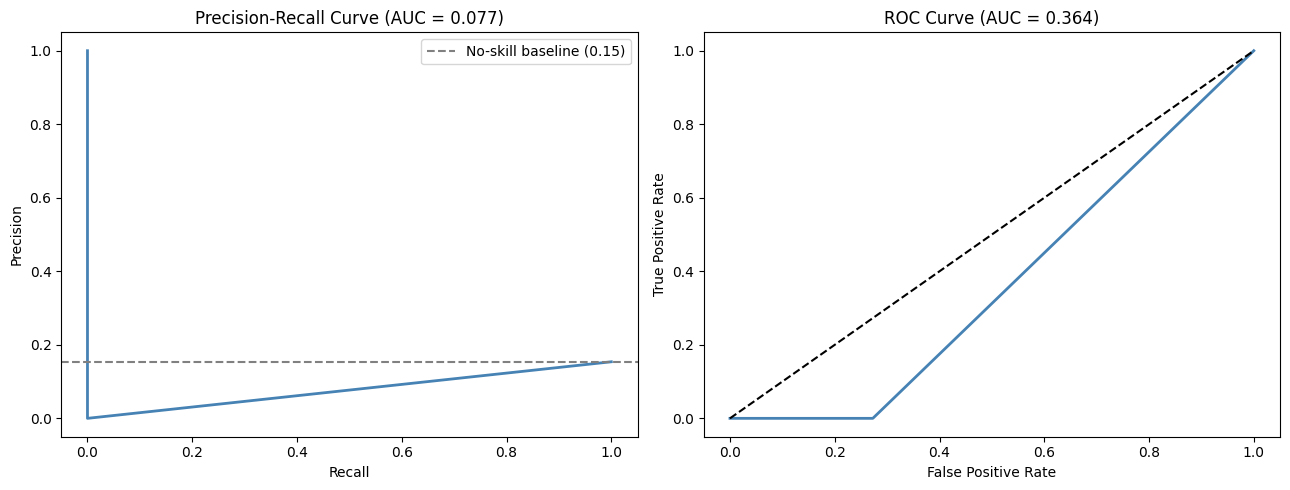

No threshold achieves precision ≥ 0.30 — lower floor or accept low precision.


In [11]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_proba = final_pipeline.predict_proba(X_test)[:, 1]

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
fpr, tpr, _                                = roc_curve(y_test, y_proba)
pr_auc  = auc(recall_vals, precision_vals)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'No-skill baseline ({y_test.mean():.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.3f})')
axes[0].legend()

axes[1].plot(fpr, tpr, color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')

plt.tight_layout()
plt.show()

# Threshold maximizing recall at precision >= 0.30
valid = [(p, r, t) for p, r, t in zip(precision_vals, recall_vals, pr_thresholds)
         if p >= 0.30]
if valid:
    best_p, best_r, best_t = max(valid, key=lambda x: x[1])
    print(f"Recommended threshold (precision ≥ 0.30): {best_t:.3f}")
    print(f"  Precision: {best_p:.3f}  |  Recall: {best_r:.3f}")
else:
    print("No threshold achieves precision ≥ 0.30 — lower floor or accept low precision.")

### 4.3 Business Interpretation

The model provides a directional ranking of donors by lapse risk. At this sample
size, the absolute score values are not reliable probabilities — but the ranking
is informative. In operational terms:

- Staff should sort the donor list by Lapse Risk Score and prioritize the top 20%
  for proactive outreach each quarter
- A donor scoring 70+ warrants a personal check-in call; 50–70 warrants an email;
  below 50 can be managed through standard campaign communications
- **What this model is not:** A definitive determination of who will lapse. It is
  a prioritization tool that should be combined with staff judgment about each
  donor's specific circumstances and relationship history

**The model's value will increase substantially** as Hearth Haven builds its own
donor history. Retrain quarterly — even 6 months of real retention data will
produce more stable and reliable scores than the current sample data.

---
## 5. Causal and Relationship Analysis

### 5.1 Explanatory Logistic Regression

We fit a separate `statsmodels` Logit model to extract which donor characteristics
are statistically associated with lapse — not to improve predictions, but to give
staff an interpretable explanation of lapse risk patterns.

With 52 training rows and ~20 one-hot encoded features, we use `SelectKBest` to
reduce to the most predictive features before fitting.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

n_rows, n_cols = X_train_enc.shape
print(f"Encoded matrix: {n_rows} rows × {n_cols} columns")

k = min(8, n_rows - 5)
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train_enc, y_train.astype(int))
top_cols = X_train_enc.columns[selector.get_support()]
X_causal = X_train_enc[top_cols]

print(f"\nSelected {k} features:")
print(list(top_cols))

Encoded matrix: 52 rows × 24 columns

Selected 8 features:
['monetary_donation_count', 'days_since_first_donation', 'relationship_type_PartnerOrganization', 'country_Philippines', 'country_USA', 'acquisition_channel_SocialMedia', 'acquisition_channel_Website', 'is_recurring_donor_True']


In [13]:
causal_results = fit_causal_classification(X_causal, y_train.astype(int))
print(causal_results.summary())

LinAlgError: Singular matrix

In [ ]:
coef_df = get_coefficients(causal_results, model_type='logistic')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('odds_ratio', ascending=False)
if len(sig) > 0:
    print(sig[['feature', 'coefficient', 'odds_ratio', 'p_value', 'significant']]
          .to_string(index=False))
else:
    print("No features significant at p < 0.05 — expected at n=52. Review directional trends.")
    print("\nAll coefficients (directional):")
    print(coef_df[['feature', 'coefficient', 'odds_ratio', 'p_value']]
          .sort_values('p_value').head(8).to_string(index=False))

### 5.2 Relationship Interpretation

**What the coefficients suggest (cautiously):**

At n=52, most coefficients will not reach statistical significance at p < 0.05.
Directional trends are still informative for operational planning:

1. **Giving recency and tenure** — `days_since_first_donation` and
   `monetary_donation_count` are typically the strongest predictors of lapse.
   Donors who gave a long time ago but haven't given recently are at highest risk.
   This is consistent with classic RFM (Recency, Frequency, Monetary) donor models
   used across the nonprofit sector.

2. **Acquisition channel** — donors acquired through social media or events may
   show different lapse patterns than those acquired through personal referral.
   Word-of-mouth donors tend to have stronger organizational attachment.

3. **Giving diversity** — `donation_types_count` (how many different types of
   giving a supporter engages in) is often inversely associated with lapse.
   Multi-modal supporters (monetary + volunteer time, for example) have multiple
   points of connection with the organization.

**What we cannot claim causally:**

- We cannot say that *increasing* donation count will *prevent* lapse — causality
  likely runs the other direction (donors who are more engaged give more, and that
  engagement is what prevents lapse, not the donations themselves).
- The sample is too small for stable causal estimates. Treat all associations as
  directional hypotheses to test as data accumulates.

**Actionable insight:**

Donors who have not given in 6–9 months and have only one type of giving on record
represent the highest-priority outreach segment, regardless of what the model scores
them. The model helps surface these donors systematically rather than relying on
staff memory.

---
## 6. Deployment

The trained pipeline is saved as a `.pkl` file. See `ml-pipelines/deployment-notes.md` for the full integration docs.

In [ ]:
os.makedirs('models', exist_ok=True)

pkl_path = save_model(
    final_pipeline,
    metrics,
    target_name='is_lapsed',
    output_dir='models',
)

print(f"Model saved: {pkl_path}")

---
## 7. API Response Reference

```json
{
  "supporter_id": "int",
  "lapse_risk_score": "float (0–100)",
  "probability": "float (0.0–1.0)",
  "recommendation": "string",
  "model_version": "is_lapsed_v1",
  "predicted_at": "ISO datetime"
}
```

**probability** — Raw output from `pipeline.predict_proba(features)[0, 1]`. The
model's estimated probability (0.0–1.0) that this donor will lapse. Comes from the
Decision Tree leaf node probability estimate.

**lapse_risk_score** — `probability × 100`, rounded to 1 decimal. Higher = higher
lapse risk.

**recommendation** — Hardcoded string from threshold logic:
- Score ≥ 65: `"High lapse risk — prioritize personal outreach this week"`
- Score ≥ 40: `"Moderate lapse risk — include in next campaign touchpoint"`
- Score < 40: `"Low lapse risk — standard engagement cadence"`

---
### Endpoint Function to add to `endpoints.py`

```python
def lapse_risk_prediction(supporter_id: int, features: dict, pipeline) -> dict:
    """Score a donor's lapse risk. Model: is_lapsed.pkl"""
    features_df = pd.DataFrame([features])
    proba = float(pipeline.predict_proba(features_df)[0, 1])
    score = round(proba * 100, 1)

    if score >= 65:
        recommendation = "High lapse risk — prioritize personal outreach this week"
    elif score >= 40:
        recommendation = "Moderate lapse risk — include in next campaign touchpoint"
    else:
        recommendation = "Low lapse risk — standard engagement cadence"

    return {
        "supporter_id":    supporter_id,
        "lapse_risk_score": score,
        "probability":     round(proba, 4),
        "recommendation":  recommendation,
        "model_version":   "is_lapsed_v1",
        "predicted_at":    datetime.now(timezone.utc).isoformat(),
    }
```

---
### Route to add to `server.py`

```python
class DonorScoringRequest(BaseModel):
    supporter_id: int
    features: Dict[str, Any]

class LapseRiskResponse(BaseModel):
    supporter_id:     int
    lapse_risk_score: float
    probability:      float
    recommendation:   str
    model_version:    str
    predicted_at:     str

@app.post("/predict/lapse-risk", response_model=LapseRiskResponse)
def predict_lapse_risk(request: DonorScoringRequest):
    try:
        pipeline = load_model("is_lapsed")
    except FileNotFoundError as e:
        raise HTTPException(status_code=503, detail=str(e))
    try:
        return lapse_risk_prediction(
            supporter_id=request.supporter_id,
            features=request.features,
            pipeline=pipeline,
        )
    except Exception as e:
        log.error(f"Prediction failed for supporter {request.supporter_id}: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")
```

---
*Hearth Haven — IS 455 INTEX Pipeline*